# IA340 Mini Project

**Electronic Vehicle Population Data**

# “How has the number of electric vehicles grown over time by type (Battery Electric vs Plug-in Hybrid)?” 

## DataSet Documentation 
- Source - https://catalog.data.gov/dataset/electric-vehicle-population-data
- Description - Electric Vehicle Population Data
- Time Period - 2000 - 2026
- Why was this data set selected?


    This data set was selected because of its wide range of information dealing with electric cars and plug in hybrid placing strong empasis on the research question 

# Import

In [35]:
import pandas as pd 

df = pd.read_csv( "s3://ia-340-2025-fall-kncxmxnzk2484/Electric_Vehicle_Population_Data.csv" ) 
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTDKN3DP2D,Yakima,Yakima,WA,98902.0,2013,TOYOTA,PRIUS,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,6.0,0.0,15.0,165252538,POINT (-120.51904 46.59783),PACIFICORP,5.307700e+10
1,1FMCU0E1XS,Kitsap,Port Orchard,WA,98366.0,2025,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,37.0,0.0,26.0,278572521,POINT (-122.63847 47.54103),PUGET SOUND ENERGY INC,5.303509e+10
2,JM3KKBHA9R,Kitsap,Kingston,WA,98346.0,2024,MAZDA,CX-90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,0.0,23.0,275123642,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,7SAYGDEE8P,Thurston,Olympia,WA,98501.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,35.0,249569323,POINT (-122.89165 47.03954),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJ3E1EB5K,Thurston,Rainier,WA,98576.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,20.0,283135107,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,5.306701e+10


# Clean

In [36]:
print("--- DataFrame Info ---")
df.info()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261698 entries, 0 to 261697
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         261698 non-null  object 
 1   County                                             261688 non-null  object 
 2   City                                               261688 non-null  object 
 3   State                                              261698 non-null  object 
 4   Postal Code                                        261688 non-null  float64
 5   Model Year                                         261698 non-null  int64  
 6   Make                                               261698 non-null  object 
 7   Model                                              261698 non-null  object 
 8   Electric Vehicle Type                              

In [37]:
print("\n--- Descriptive Statistics for Numeric Columns ---")
print(df.describe())


--- Descriptive Statistics for Numeric Columns ---
         Postal Code     Model Year  Electric Range      Base MSRP  \
count  261688.000000  261698.000000   261695.000000  261695.000000   
mean    98176.150699    2021.772493       42.615071     695.503563   
std      2555.753410       3.034041       81.226054    6943.019653   
min      1469.000000    2000.000000        0.000000       0.000000   
25%     98052.000000    2020.000000        0.000000       0.000000   
50%     98133.000000    2023.000000        0.000000       0.000000   
75%     98382.000000    2024.000000       35.000000       0.000000   
max     99577.000000    2026.000000      337.000000  845000.000000   

       Legislative District  DOL Vehicle ID  2020 Census Tract  
count         261070.000000    2.616980e+05       2.616880e+05  
mean              28.881955    2.412577e+08       5.297261e+10  
std               14.889697    6.574252e+07       1.628791e+09  
min                1.000000    4.385000e+03       1.00102

In [38]:
print("\nMissing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
VIN (1-10)                                             0
County                                                10
City                                                  10
State                                                  0
Postal Code                                           10
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         3
Base MSRP                                              3
Legislative District                                 628
DOL Vehicle ID                                         0
Vehicle Location                                      18
Electric Utility                                      10
2020 Census Tract                                     1

In [39]:
core_cols = ['County', 'Model Year', 'Electric Vehicle Type']
rows_before = len(df)
df.dropna(subset=core_cols, inplace=True)
rows_after = len(df)
print(f"\nMissing value handling: Dropped {rows_before - rows_after} rows with missing core data.")



Missing value handling: Dropped 10 rows with missing core data.


In [40]:
duplicates_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
duplicates_after = df.duplicated().sum()
print(f"Duplicate removal: Removed {duplicates_before - duplicates_after} rows.")

Duplicate removal: Removed 0 rows.


In [41]:
invalid_year_count = len(df[df['Model Year'] < 1990])
df = df[df['Model Year'] >= 1990].copy()
print(f"Validity check: Removed {invalid_year_count} records with 'Model Year' before 1990.")


Validity check: Removed 0 records with 'Model Year' before 1990.


In [42]:
df['Model Year'] = df['Model Year'].astype(int)

In [43]:
print("\nFinal clean DataFrame sample:")
print(df.head())
print("\nFinal clean DataFrame info:")
df.info()


Final clean DataFrame sample:
   VIN (1-10)    County          City State  Postal Code  Model Year    Make  \
0  JTDKN3DP2D    Yakima        Yakima    WA      98902.0        2013  TOYOTA   
1  1FMCU0E1XS    Kitsap  Port Orchard    WA      98366.0        2025    FORD   
2  JM3KKBHA9R    Kitsap      Kingston    WA      98346.0        2024   MAZDA   
3  7SAYGDEE8P  Thurston       Olympia    WA      98501.0        2023   TESLA   
4  5YJ3E1EB5K  Thurston       Rainier    WA      98576.0        2019   TESLA   

     Model                   Electric Vehicle Type  \
0    PRIUS  Plug-in Hybrid Electric Vehicle (PHEV)   
1   ESCAPE  Plug-in Hybrid Electric Vehicle (PHEV)   
2    CX-90  Plug-in Hybrid Electric Vehicle (PHEV)   
3  MODEL Y          Battery Electric Vehicle (BEV)   
4  MODEL 3          Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0              Not eligible due to low battery range             6.0   
1            Clean 

**There were zero duplicates but the code dropped 10 rows of missing data and those were the only changes.**

## Process and Agregate

In [66]:
# Assuming 'df' is the clean DataFrame from the previous step.

# 1. Identify the most recent 5 model years
max_year = df['Model Year'].max()
recent_years = [y for y in range(max_year - 4, max_year + 1)]
print(f"Focusing on recent model years: {recent_years}")

# 2. Identify the top 3 counties by cumulative EV population (overall count)
# This uses the full cleaned dataset (df) to determine the top counties
county_counts = df['County'].value_counts()
top_3_counties = county_counts.index.tolist()[:3]
print(f"\nTop 3 Counties by Total EV Count: {top_3_counties}")

# 3. Filter the clean data for the top 3 counties and the recent years
df_filtered = df[
    (df['County'].isin(top_3_counties)) &
    (df['Model Year'].isin(recent_years))
].copy()

# 4. Create the Summary Table: Group by County, Model Year, and EV Type
# and count the vehicle population (EV_Count)
yearly_county_summary = df_filtered.groupby(
    ['County', 'Model Year', 'Electric Vehicle Type']
).size().reset_index(name='EV_Count')

# 5. Calculate Total EVs per County per Year for proportion calculation
# The .transform('sum') function applies the sum back to every row in that group.
yearly_county_summary['Total_EVs_Year'] = yearly_county_summary.groupby(
    ['County', 'Model Year']
)['EV_Count'].transform('sum')

# 6. Create a new variable: Proportion of each EV type
yearly_county_summary['Proportion'] = (
    yearly_county_summary['EV_Count'] / yearly_county_summary['Total_EVs_Year']
) * 100

print("\n--- Yearly County EV Proportion Summary Table (First 10 Rows) ---")
print(yearly_county_summary.head(10))

Focusing on recent model years: [2022, 2023, 2024, 2025, 2026]

Top 3 Counties by Total EV Count: ['King', 'Snohomish', 'Pierce']

--- Yearly County EV Proportion Summary Table (First 10 Rows) ---
  County  Model Year                   Electric Vehicle Type  EV_Count  \
0   King        2022          Battery Electric Vehicle (BEV)     12779   
1   King        2022  Plug-in Hybrid Electric Vehicle (PHEV)      2139   
2   King        2023          Battery Electric Vehicle (BEV)     27813   
3   King        2023  Plug-in Hybrid Electric Vehicle (PHEV)      3425   
4   King        2024          Battery Electric Vehicle (BEV)     19728   
5   King        2024  Plug-in Hybrid Electric Vehicle (PHEV)      4872   
6   King        2025          Battery Electric Vehicle (BEV)     12149   
7   King        2025  Plug-in Hybrid Electric Vehicle (PHEV)      3420   
8   King        2026          Battery Electric Vehicle (BEV)      2770   
9   King        2026  Plug-in Hybrid Electric Vehicle (PHEV)   

**Top 3 countries, yearly county summary, and proportion were the new variables added because this aggregation directly calculates the proportions of BEV versus PHEV within the top three counties across the most recent five model years, which is the primary focus of the research question.** 

## Query

In [67]:
# Apply a meaningful filter: Select all County/Year combinations 
# where Battery Electric Vehicles (BEV) make up more than 80% of the total EV population.

# 1. Filter the summary table for Battery Electric Vehicles (BEV) records
bev_summary = yearly_county_summary[
    yearly_county_summary['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)'
].copy()

# 2. Define the threshold (80%) and apply the filter
bev_threshold = 80
bev_dominant_query = bev_summary[
    bev_summary['Proportion'] > bev_threshold
].sort_values(by='Model Year', ascending=False) # Sort to easily see the most recent dominance

# Show results in a DataFrame
print(f"\n--- Query Results: County/Years where BEVs Exceeded {bev_threshold}% of Registrations ---")
print(bev_dominant_query)


--- Query Results: County/Years where BEVs Exceeded 80% of Registrations ---
       County  Model Year           Electric Vehicle Type  EV_Count  \
8        King        2026  Battery Electric Vehicle (BEV)      2770   
28  Snohomish        2026  Battery Electric Vehicle (BEV)       763   
18     Pierce        2026  Battery Electric Vehicle (BEV)       490   
26  Snohomish        2025  Battery Electric Vehicle (BEV)      3143   
4        King        2024  Battery Electric Vehicle (BEV)     19728   
24  Snohomish        2024  Battery Electric Vehicle (BEV)      5260   
14     Pierce        2024  Battery Electric Vehicle (BEV)      3580   
2        King        2023  Battery Electric Vehicle (BEV)     27813   
12     Pierce        2023  Battery Electric Vehicle (BEV)      3910   
22  Snohomish        2023  Battery Electric Vehicle (BEV)      7383   
0        King        2022  Battery Electric Vehicle (BEV)     12779   
10     Pierce        2022  Battery Electric Vehicle (BEV)      1853   

**The filter was applied to identify the specific counties and model years where Battery Electric Vehicles (BEVs) achieved clear market dominance by making up over 80% of the total EV registrations. This way was chosen to provide a  result that directly supports the finding that BEVs are becoming the preferred electric vehicle type.**

## Visualizations 

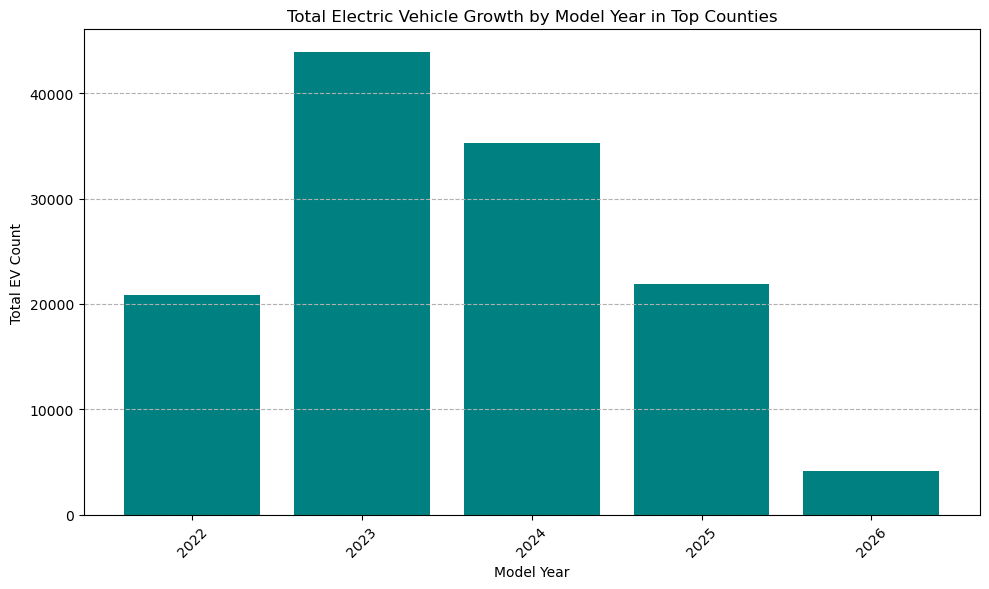

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Aggregate the yearly_county_summary to get total EV count by Model Year
annual_ev_growth = yearly_county_summary.groupby('Model Year')['EV_Count'].sum().reset_index()

# 2. Generate the Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(
    # Convert year to string for a cleaner categorical x-axis display
    annual_ev_growth['Model Year'].astype(str), 
    annual_ev_growth['EV_Count'], 
    color='teal'
)

plt.title('Total Electric Vehicle Growth by Model Year in Top Counties')
plt.xlabel('Model Year')
plt.ylabel('Total EV Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**The chart demonstrates that the popularity of electric vehicles is shifting towards Battery Electric Vehicles (BEV). In the most recent model years, the BEV proportion (the teal/blue segment) dominates the market, taking over 90% of the electric vehicle registrations in these counties, while PHEV popularity has shrunk.**

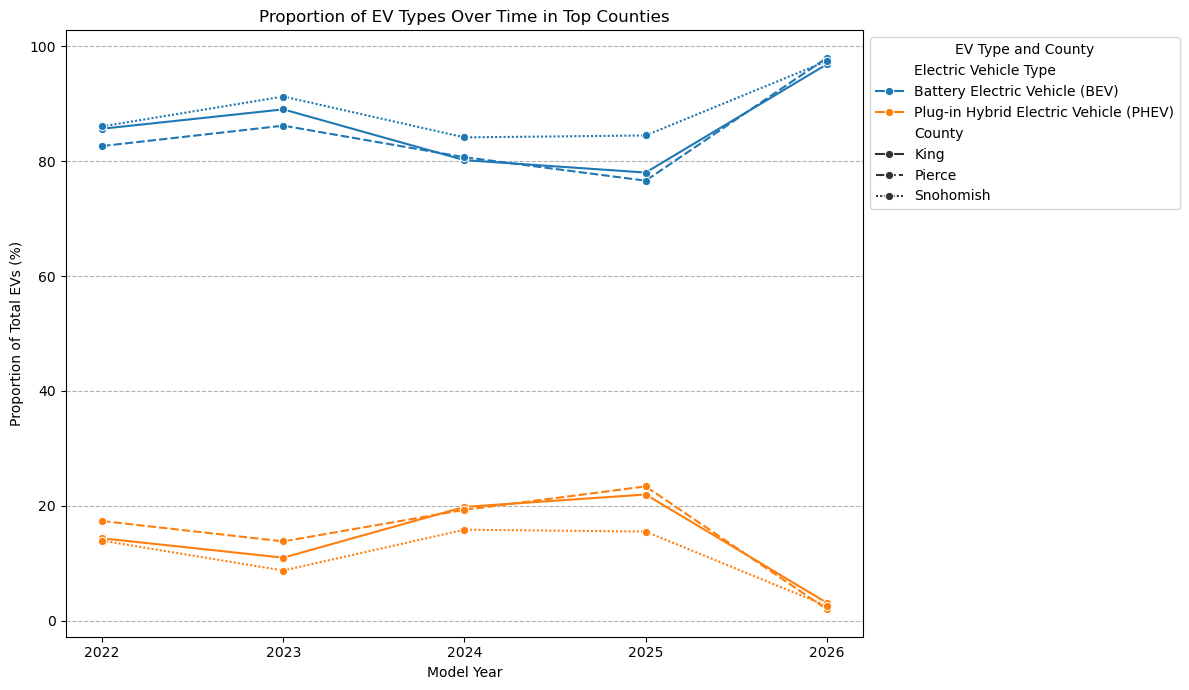

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=yearly_county_summary,
    x='Model Year',
    y='Proportion',
    hue='Electric Vehicle Type', # Separate lines by EV Type (color)
    style='County',              # Separate line styles by County (dash/dot)
    marker='o'
)

plt.title('Proportion of EV Types Over Time in Top Counties')
plt.xlabel('Model Year')
plt.ylabel('Proportion of Total EVs (%)')
plt.xticks(yearly_county_summary['Model Year'].unique()) # Ensure ticks are only on existing years
plt.legend(title='EV Type and County', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**This visualization confirms the trend shown in the first chart by revealing that the number of BEV registrations growing over time across top counties. The steep upward slope of the lines indicates that the growth of electric vehicles is driven almost entirely by the increasing volume of fully-electric BEVs entering the market.**